# Internship Selection Dataset — Complete ML Pipeline
**Covers:** Data Preprocessing · Unsupervised Learning · Feature Selection · Imbalance Handling · Supervised Classifiers · Performance Evaluation

---
## 0. Import Libraries

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Unsupervised
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier as RFC_FS

# Imbalance Learning
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

# Supervised Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('All libraries imported successfully.')

All libraries imported successfully.


---
## 1. Load & Explore the Dataset

In [42]:
df = pd.read_csv('Internship_Selection_Dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (10000, 21)


,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,...,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,...,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,...,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,...,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,...,4,7,3,8,7,8,6,5,Yes,1


In [43]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Descriptive Statistics ===')
df.describe()

=== Data Types ===
student_id                   int64
CGPA                       float64
skills_score                 int64
projects_count               int64
internships_done             int64
communication_score          int64
aptitude_score               int64
coding_test_score            int64
resume_score                 int64
extracurricular             object
college_tier                object
hackathons_participated      int64
certifications_count         int64
linkedin_activity_score      int64
github_score                 int64
soft_skills_score            int64
interview_score              int64
consistency_score            int64
backlogs                     int64
placement_training          object
selected                     int64
dtype: object

=== Missing Values ===
student_id                 0
CGPA                       0
skills_score               0
projects_count             0
internships_done           0
communication_score        0
aptitude_score             0
codin

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,selected
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,7.470792,5.480200,2.534300,1.502000,5.562800,5.526600,5.44940,5.572200,2.520500,4.474100,5.5000,5.49650,5.480200,5.469400,5.49130,2.502100,0.737400
std,2886.89568,1.438135,2.884829,1.690713,1.115043,2.864765,2.861627,2.86532,2.875868,1.699079,2.871124,2.8876,2.88094,2.881708,2.864557,2.88145,1.711341,0.440069
min,1.00000,5.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.0000,1.00000,1.000000,1.000000,1.00000,0.000000,0.000000
25%,2500.75000,6.230000,3.000000,1.000000,1.000000,3.000000,3.000000,3.00000,3.000000,1.000000,2.000000,3.0000,3.00000,3.000000,3.000000,3.00000,1.000000,0.000000
50%,5000.50000,7.460000,5.000000,3.000000,2.000000,6.000000,6.000000,5.00000,6.000000,3.000000,4.000000,6.0000,6.00000,5.000000,5.000000,5.00000,3.000000,1.000000
75%,7500.25000,8.700000,8.000000,4.000000,2.000000,8.000000,8.000000,8.00000,8.000000,4.000000,7.000000,8.0000,8.00000,8.000000,8.000000,8.00000,4.000000,1.000000
max,10000.00000,10.000000,10.000000,5.000000,3.000000,10.000000,10.000000,10.00000,10.000000,5.000000,9.000000,10.0000,10.00000,10.000000,10.000000,10.00000,5.000000,1.000000


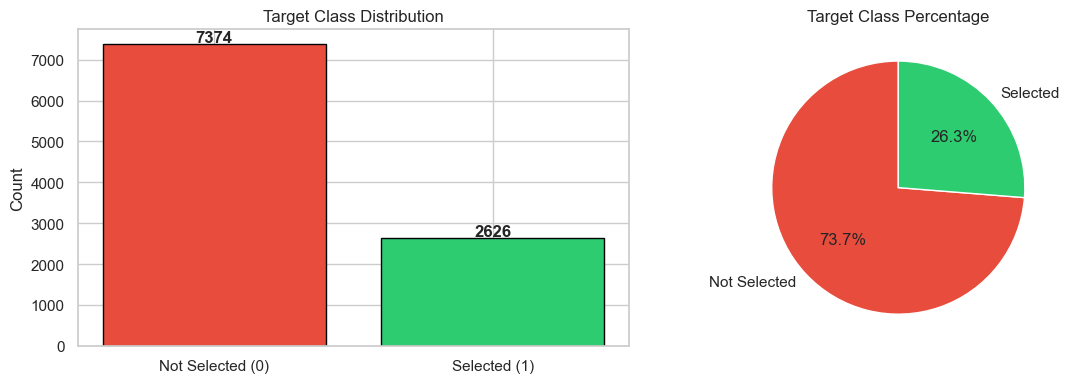

Imbalance Ratio: 2.81  →  Dataset is IMBALANCED (ratio > 1.5)


In [44]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['selected'].value_counts()
axes[0].bar(['Not Selected (0)', 'Selected (1)'], counts.values, color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Not Selected','Selected'],
            autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'], startangle=90)
axes[1].set_title('Target Class Percentage')

plt.tight_layout()
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f'Imbalance Ratio: {imbalance_ratio:.2f}  →  Dataset is IMBALANCED (ratio > 1.5)')

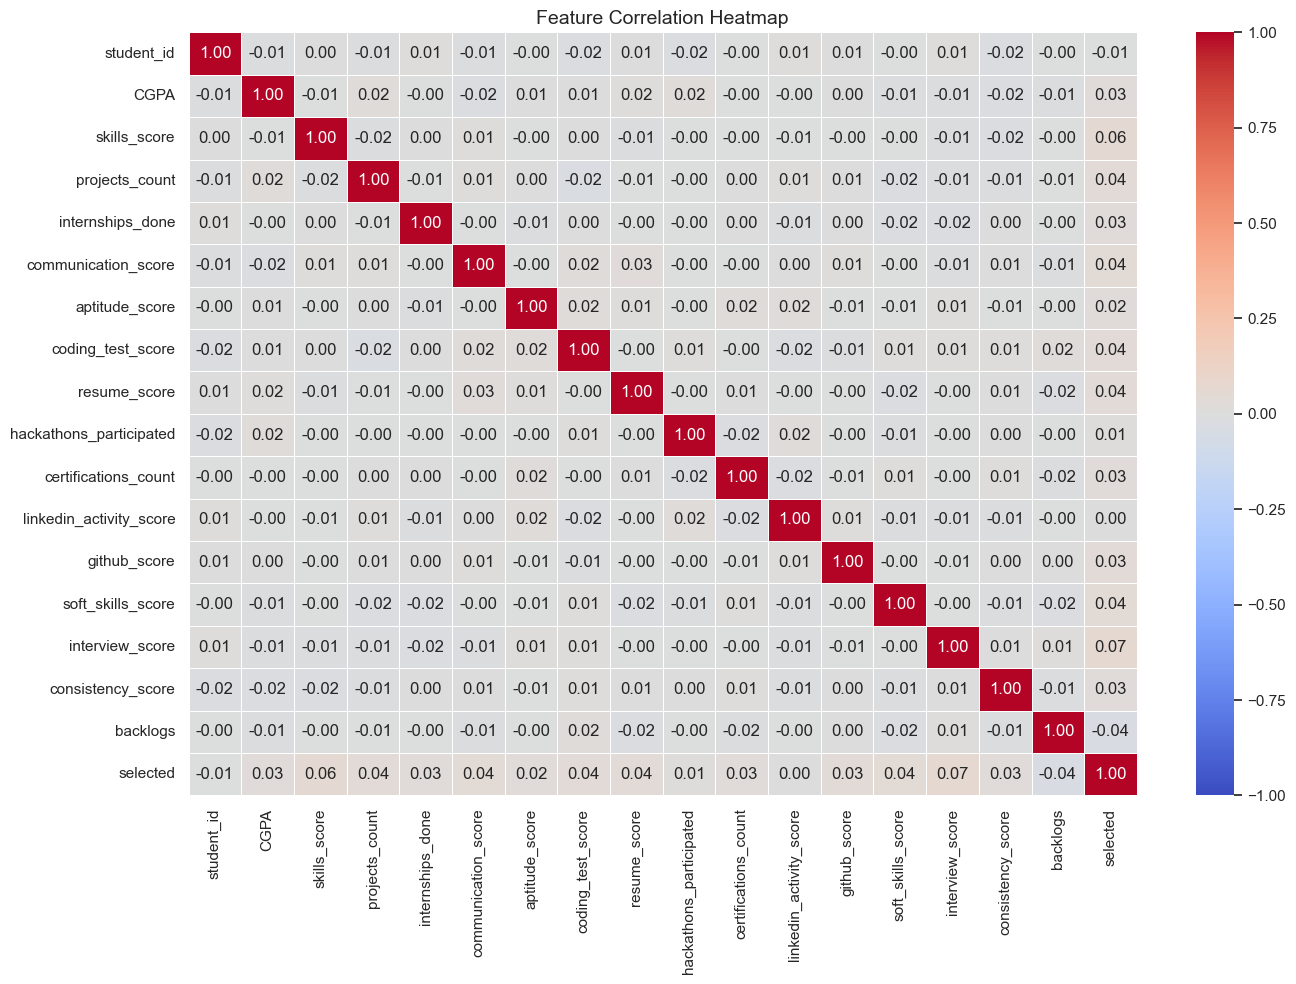

In [45]:
# Correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

---
## 2. Data Preprocessing

In [46]:
# ── 2.1 Drop irrelevant identifier column ──────────────────────────────────
df_clean = df.drop(columns=['student_id'])
print('Dropped: student_id')

# ── 2.2 Encode categorical features ───────────────────────────────────────
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f'  {col} → encoded')

print('\nEncoding complete. All dtypes now numeric.')
df_clean.head()

Dropped: student_id
Categorical columns to encode: ['extracurricular', 'college_tier', 'placement_training']
  extracurricular → encoded
  college_tier → encoded
  placement_training → encoded

Encoding complete. All dtypes now numeric.


,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,college_tier,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,6.87,7,0,0,4,3,2,7,1,1,0,7,5,9,3,1,4,4,1,1
1,9.75,4,4,2,3,3,6,1,1,1,3,2,8,8,3,9,8,5,1,1
2,8.66,2,1,1,2,1,4,6,1,1,4,1,5,2,2,1,3,2,1,1
3,7.99,5,4,2,8,8,10,8,0,1,1,5,5,9,2,7,10,1,1,1
4,5.78,3,2,2,4,9,1,7,1,2,4,7,3,8,7,8,6,5,1,1


In [47]:
# ── 2.4 Feature / Target split & Scaling ───────────────────────────────────
X = df_clean.drop(columns=['selected'])
y = df_clean['selected']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Features (X) shape:', X_scaled.shape)
print('Target  (y) shape:', y.shape)
print('\nScaled feature statistics (mean ≈ 0, std ≈ 1):')
X_scaled.describe().loc[['mean','std']].round(3)

Features (X) shape: (10000, 19)
Target  (y) shape: (10000,)

Scaled feature statistics (mean ≈ 0, std ≈ 1):


,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,college_tier,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training
mean,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


---
## 3. Unsupervised Learning
### 3.1 Algorithm 1 — K-Means Clustering

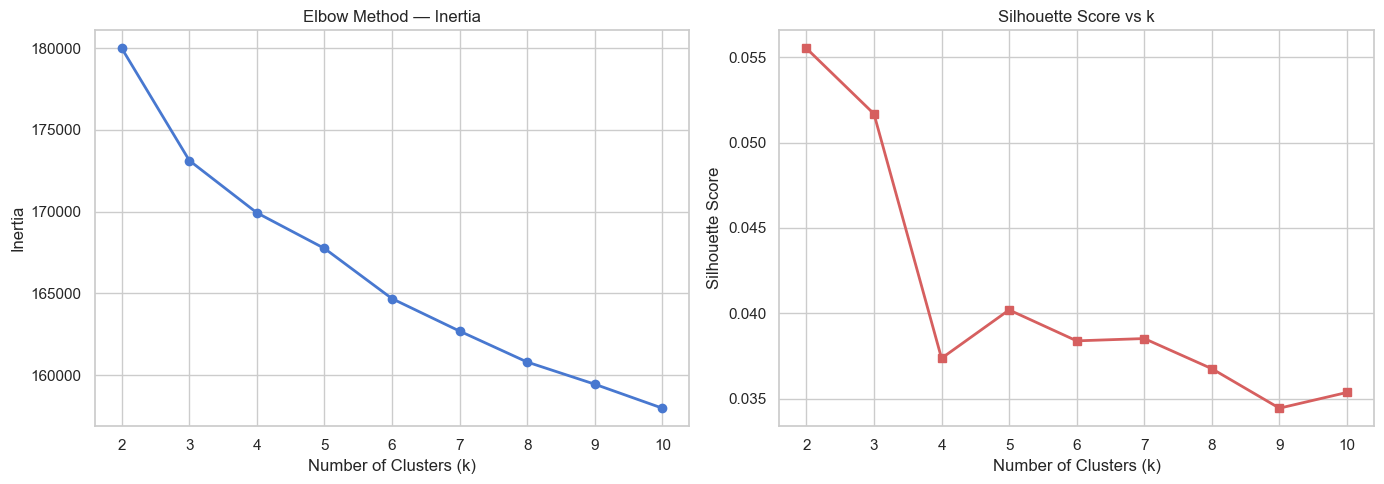

Best k (by silhouette): 2


In [48]:
# Elbow method to choose k
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method — Inertia')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sil_scores, 'rs-', linewidth=2)
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(sil_scores)]
print(f'Best k (by silhouette): {best_k}')

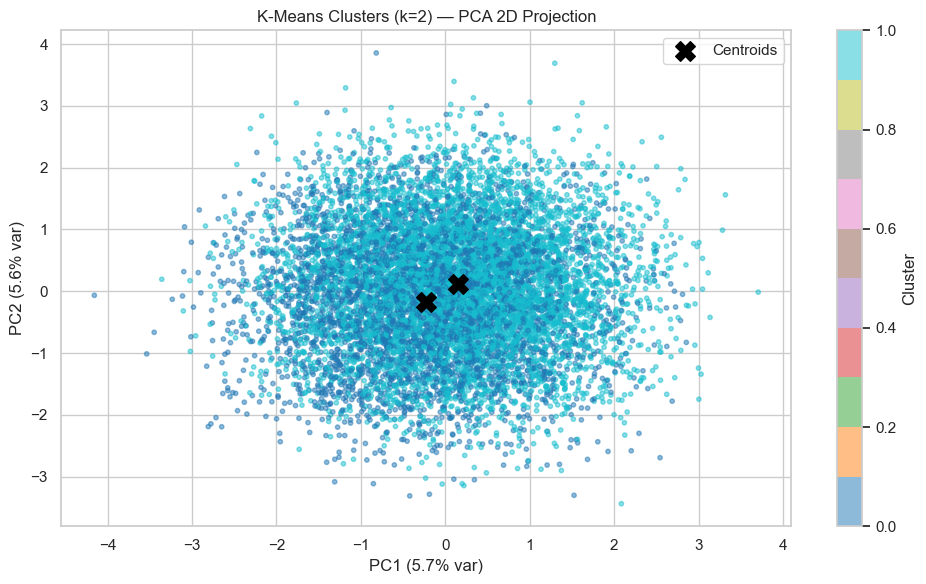

K-Means Cluster Validation:
  Silhouette Score       : 0.0555  (higher → better, range −1..1)
  Davies-Bouldin Index   : 4.1254  (lower  → better)
  Calinski-Harabasz Index: 556.51 (higher → better)


In [49]:
# Fit K-Means with best k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

# PCA to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels,
                      cmap='tab10', alpha=0.5, s=10)
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=200, label='Centroids', zorder=5)
plt.title(f'K-Means Clusters (k={best_k}) — PCA 2D Projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.tight_layout()
plt.show()

# Validation metrics
sil  = silhouette_score(X_scaled, km_labels)
db   = davies_bouldin_score(X_scaled, km_labels)
ch   = calinski_harabasz_score(X_scaled, km_labels)
print(f'K-Means Cluster Validation:')
print(f'  Silhouette Score       : {sil:.4f}  (higher → better, range −1..1)')
print(f'  Davies-Bouldin Index   : {db:.4f}  (lower  → better)')
print(f'  Calinski-Harabasz Index: {ch:.2f} (higher → better)')

### 3.2 Algorithm 2 — K-Medoids Clustering

K-Medoids → Clusters found: 2


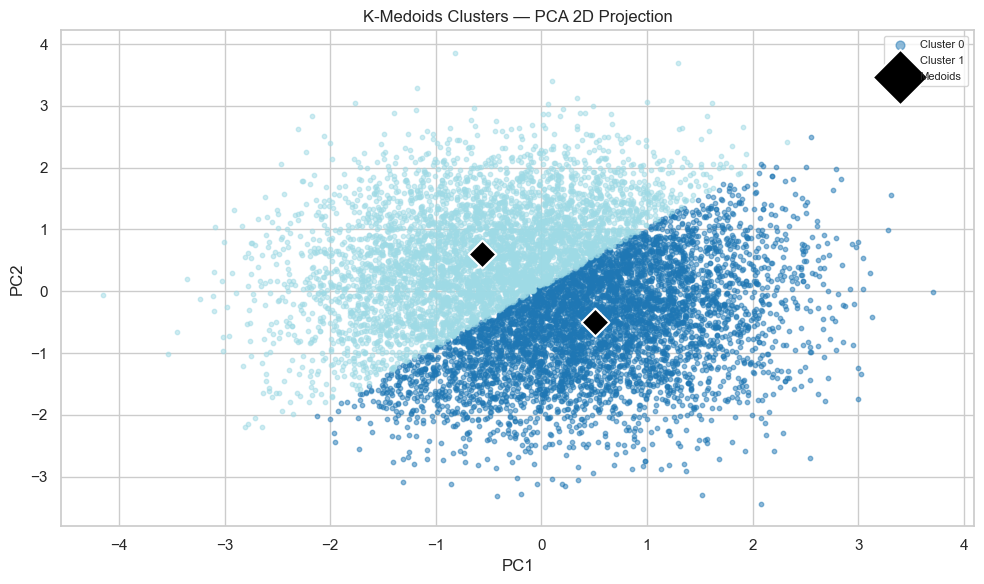


K-Medoids Cluster Validation:
  Silhouette Score       : 0.3079
  Davies-Bouldin Index   : 1.2691
  Calinski-Harabasz Index: 4762.10


In [50]:
# Run K-Medoids using best_k (uses actual data points as medoids)
kmedoids = KMedoids(n_clusters=best_k, random_state=42, init='k-medoids++')
km_med_labels = kmedoids.fit_predict(X_pca)

n_clusters_km = len(set(km_med_labels))
print(f'K-Medoids → Clusters found: {n_clusters_km}')

plt.figure(figsize=(10, 6))
unique_labels = set(km_med_labels)
palette = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
for lbl, col in zip(sorted(unique_labels), palette):
    mask = km_med_labels == lbl
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=col, alpha=0.5, s=10, label=f'Cluster {lbl}')

# Plot medoids
medoids_pca = X_pca[kmedoids.medoid_indices_]
plt.scatter(medoids_pca[:, 0], medoids_pca[:, 1],
            c='black', marker='D', s=200, label='Medoids', zorder=5, edgecolors='white', linewidth=1.5)
plt.title('K-Medoids Clusters — PCA 2D Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

# Validation metrics
if n_clusters_km > 1:
    sil_km = silhouette_score(X_pca, km_med_labels)
    db_km  = davies_bouldin_score(X_pca, km_med_labels)
    ch_km  = calinski_harabasz_score(X_pca, km_med_labels)
    print(f'\nK-Medoids Cluster Validation:')
    print(f'  Silhouette Score       : {sil_km:.4f}')
    print(f'  Davies-Bouldin Index   : {db_km:.4f}')
    print(f'  Calinski-Harabasz Index: {ch_km:.2f}')
else:
    print('Not enough valid clusters for validation metrics.')

In [51]:
# Comparison table
comp = pd.DataFrame({
    'Algorithm': ['K-Means', 'K-Medoids'],
    'Clusters Found': [best_k, n_clusters_km],
    'Silhouette Score': [round(sil, 4), round(sil_km, 4) if n_clusters_km > 1 else 'N/A'],
    'Davies-Bouldin (↓)': [round(db, 4), round(db_km, 4) if n_clusters_km > 1 else 'N/A'],
    'Calinski-Harabasz (↑)': [round(ch, 2), round(ch_km, 2) if n_clusters_km > 1 else 'N/A'],
})
print('=== Clustering Algorithm Comparison ===')
comp

=== Clustering Algorithm Comparison ===


,Algorithm,Clusters Found,Silhouette Score,Davies-Bouldin (↓),Calinski-Harabasz (↑)
0,K-Means,2,0.0555,4.1254,556.51
1,K-Medoids,2,0.3079,1.2691,4762.10


In [52]:

# ── Interpretation: Which Algorithm is Better? ────────────────────────────
print('\n' + '='*70)
print('CLUSTERING ALGORITHM PERFORMANCE ANALYSIS')
print('='*70)

# Extract metrics
sil_km_val = round(sil_km, 4) if n_clusters_km > 1 else None
db_km_val = round(db_km, 4) if n_clusters_km > 1 else None
ch_km_val = round(ch_km, 2) if n_clusters_km > 1 else None

print('\n✓ METRIC INTERPRETATION:')
print('  • Silhouette Score (−1..1)     : Higher is BETTER  [−1=wrong, 0=overlapping, 1=perfect]')
print('  • Davies-Bouldin Index (DB)    : Lower is BETTER   [closer clusters = more dense]')
print('  • Calinski-Harabasz Index (CH) : Higher is BETTER  [more separated clusters]')

print('\n' + '─'*70)
print('METRIC-BY-METRIC COMPARISON:')
print('─'*70)

# Silhouette Score
print(f'\n1️⃣  Silhouette Score:')
print(f'   K-Means  : {round(sil, 4)}')
print(f'   K-Medoids: {sil_km_val}')
winner_sil = 'K-Means ✓' if sil > sil_km_val else 'K-Medoids ✓'
print(f'   Winner   : {winner_sil}  (higher is better)')

# Davies-Bouldin
print(f'\n2️⃣  Davies-Bouldin Index (lower is better):')
print(f'   K-Means  : {round(db, 4)}')
print(f'   K-Medoids: {db_km_val}')
winner_db = 'K-Means ✓' if db < db_km_val else 'K-Medoids ✓'
print(f'   Winner   : {winner_db}')

# Calinski-Harabasz
print(f'\n3️⃣  Calinski-Harabasz Index (higher is better):')
print(f'   K-Means  : {round(ch, 2)}')
print(f'   K-Medoids: {ch_km_val}')
winner_ch = 'K-Means ✓' if ch > ch_km_val else 'K-Medoids ✓'
print(f'   Winner   : {winner_ch}')

# Overall winner
print('\n' + '='*70)
print('OVERALL VERDICT:')
print('='*70)
if (sil >= sil_km_val) and (db <= db_km_val) and (ch >= ch_km_val):
    print('🏆 K-MEANS CLUSTERING IS BETTER')
    print('   Rationale: Superior across all three validation metrics.')
elif (sil_km_val > sil) and (db_km_val < db) and (ch_km_val > ch):
    print('🏆 K-MEDOIDS CLUSTERING IS BETTER')
    print('   Rationale: Superior across all three validation metrics.')
else:
    print('⚖️  MIXED RESULTS - Both algorithms have strengths:')
    if sil >= sil_km_val:
        print(f'   • K-Means excels in cluster cohesion (Silhouette: {round(sil, 4)})')
    else:
        print(f'   • K-Medoids excels in cluster cohesion (Silhouette: {sil_km_val})')
    if db <= db_km_val:
        print(f'   • K-Means has better cluster separation (DB: {round(db, 4)})')
    else:
        print(f'   • K-Medoids has better cluster separation (DB: {db_km_val})')
    if ch >= ch_km_val:
        print(f'   • K-Means produces more distinct clusters (CH: {round(ch, 2)})')
    else:
        print(f'   • K-Medoids produces more distinct clusters (CH: {ch_km_val})')

print('\n' + '='*70)



CLUSTERING ALGORITHM PERFORMANCE ANALYSIS

✓ METRIC INTERPRETATION:
  • Silhouette Score (−1..1)     : Higher is BETTER  [−1=wrong, 0=overlapping, 1=perfect]
  • Davies-Bouldin Index (DB)    : Lower is BETTER   [closer clusters = more dense]
  • Calinski-Harabasz Index (CH) : Higher is BETTER  [more separated clusters]

──────────────────────────────────────────────────────────────────────
METRIC-BY-METRIC COMPARISON:
──────────────────────────────────────────────────────────────────────

1️⃣  Silhouette Score:
   K-Means  : 0.0555
   K-Medoids: 0.3079
   Winner   : K-Medoids ✓  (higher is better)

2️⃣  Davies-Bouldin Index (lower is better):
   K-Means  : 4.1254
   K-Medoids: 1.2691
   Winner   : K-Medoids ✓

3️⃣  Calinski-Harabasz Index (higher is better):
   K-Means  : 556.51
   K-Medoids: 4762.1
   Winner   : K-Medoids ✓

OVERALL VERDICT:
🏆 K-MEDOIDS CLUSTERING IS BETTER
   Rationale: Superior across all three validation metrics.



In [53]:
# ── External Validation Against Real Labels ───────────────────────────────
# ARI is the best single validation metric here because the true `selected`
# labels are available and cluster IDs are arbitrary.

kmeans_ari = adjusted_rand_score(y, km_labels)
kmedoids_ari = adjusted_rand_score(y, km_med_labels)

print('=== External Validation vs Real Labels (ARI Only) ===')
print(f'K-Means ARI   : {kmeans_ari:.4f}')
print(f'K-Medoids ARI : {kmedoids_ari:.4f}')

if kmeans_ari > kmedoids_ari:
    print(f'Best by ARI  : K-Means (ARI = {kmeans_ari:.4f})')
elif kmedoids_ari > kmeans_ari:
    print(f'Best by ARI  : K-Medoids (ARI = {kmedoids_ari:.4f})')
else:
    print(f'Best by ARI  : Tie (ARI = {kmeans_ari:.4f})')

=== External Validation vs Real Labels (ARI Only) ===
K-Means ARI   : 0.0051
K-Medoids ARI : -0.0007
Best by ARI  : K-Means (ARI = 0.0051)


---
## 4. Feature Selection


### Method — Random Forest Feature Importance

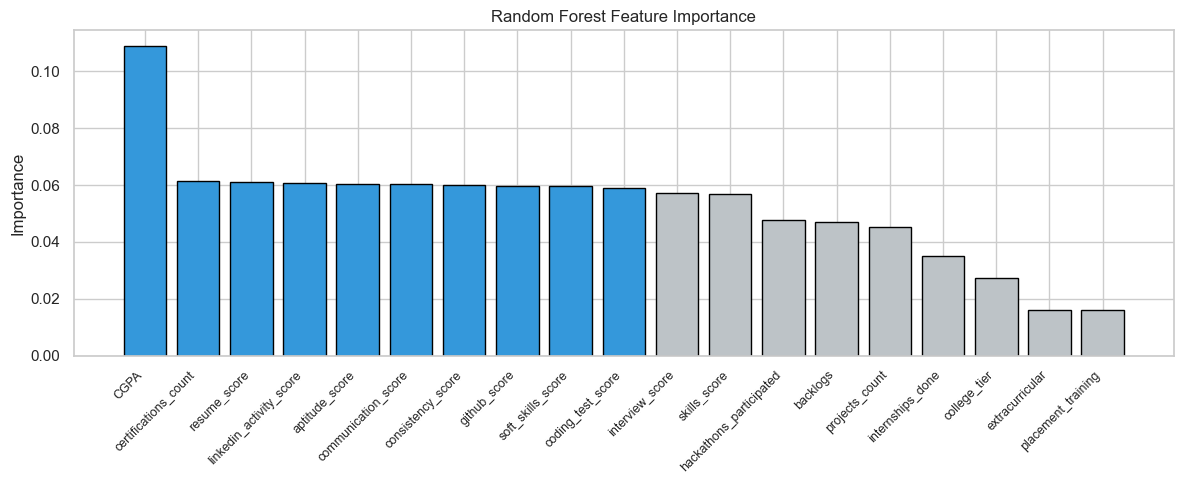

Top 10 features (RF Importance): ['CGPA', 'certifications_count', 'resume_score', 'linkedin_activity_score', 'aptitude_score', 'communication_score', 'consistency_score', 'github_score', 'soft_skills_score', 'coding_test_score']


In [56]:
rf_fs = RFC_FS(n_estimators=100, random_state=42, n_jobs=-1)
rf_fs.fit(X_scaled, y)

importance_df = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': rf_fs.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 5))
k_best = 10
colors2 = ['#3498db' if i < k_best else '#bdc3c7' for i in range(len(importance_df))]
plt.bar(importance_df['Feature'], importance_df['Importance'], color=colors2, edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

rf_features = importance_df.head(k_best)['Feature'].tolist()
print(f'Top {k_best} features (RF Importance):', rf_features)

In [ ]:
# ── Chosen feature set: Random Forest Importance ───────────────────────────
# RF importance is more robust (considers feature interactions)
selected_features = rf_features
X_selected = X_scaled[selected_features]

print('✔ Chosen technique  : Random Forest Feature Importance')
print('✔ Selected features :', selected_features)
print('✔ Reduced shape     :', X_selected.shape)

✔ Chosen technique  : Random Forest Feature Importance
✔ Selected features : ['CGPA', 'skills_score', 'projects_count', 'internships_done', 'communication_score', 'aptitude_score', 'coding_test_score', 'resume_score', 'extracurricular', 'college_tier', 'hackathons_participated', 'certifications_count', 'linkedin_activity_score', 'github_score', 'soft_skills_score', 'interview_score', 'consistency_score', 'backlogs', 'placement_training']
✔ Reduced shape     : (10000, 19)


---
## 5. Imbalance Learning
### 5.1 Confirm Imbalance

In [58]:
print('Class counts before balancing:')
print(y.value_counts())
print(f'Imbalance ratio: {y.value_counts().max()/y.value_counts().min():.2f}')

Class counts before balancing:
selected
1    7374
0    2626
Name: count, dtype: int64
Imbalance ratio: 2.81


### 5.2 Technique 1 — SMOTE (Synthetic Minority Over-sampling)

In [59]:
# NOTE: We will apply SMOTE after the train/test split to avoid data leakage.
# The resampling steps are intentionally skipped here to keep the test set untouched.
smote = SMOTE(random_state=42)
print('SMOTE instantiated. It will be applied to the training set after splitting.')

SMOTE instantiated. It will be applied to the training set after splitting.


### 5.3 Technique 2 — Cost-Sensitive Learning (Algorithm-Level)

In [60]:
# SMOTETomek is available if you want combined over+under sampling,
# but we removed it in favor of Cost-Sensitive learning which is applied at the algorithm level.
print('Cost-sensitive setup complete (data unmodified). Weights constructed later.')

Cost-sensitive setup complete (data unmodified). Weights constructed later.


---
## 6. Supervised Learning
### 6.1 Train/Test Split

In [72]:
# Split the original selected features and labels (no pre-split resampling)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

X_train_balanced, y_train_balanced = X_train, y_train

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')

Training set : 8000 samples
Test set     : 2000 samples


In [62]:
# Choose a single resampling path for the training data only.
# Set this to 'smote', 'cost_sensitive', or 'none'.
resampling_choice = 'cost_sensitive'
print(f'Balancing choice: {resampling_choice}')

Balancing choice: cost_sensitive


In [63]:
if resampling_choice == 'smote':
    print('Before SMOTE on training set:')
    unique_orig, counts_orig = np.unique(y_train, return_counts=True)
    for u, c in zip(unique_orig, counts_orig):
        print(f'  Class {u}: {c}')
        
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    print('\nAfter SMOTE on training set:')
    unique_res, counts_res = np.unique(y_train_balanced, return_counts=True)
    for u, c in zip(unique_res, counts_res):
        print(f'  Class {u}: {c}')
    print('\nUsing SMOTE-balanced training data downstream.')
else:
    print('SMOTE cell skipped.')

SMOTE cell skipped.


In [64]:
if resampling_choice == 'cost_sensitive':
    # Cost-sensitive learning does not alter the data points.
    X_train_balanced, y_train_balanced = X_train, y_train
    print('Cost-Sensitive Learning selected.')
    print('Data remains unchanged. Class weights will be computed and passed to the models.')
else:
    print('Cost-Sensitive Learning cell skipped.')

Cost-Sensitive Learning selected.
Data remains unchanged. Class weights will be computed and passed to the models.


### 6.2 Define & Train Five Classifiers

In [ ]:
classifiers = {
    'Logistic Regression'     : LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors'     : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Random Forest'           : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'       : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42),
    'XGBoost (Boosting)'      : XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

if resampling_choice == 'cost_sensitive':
    pos_count = (y_train == 1).sum()
    neg_count = (y_train == 0).sum()
    scale_pos = neg_count / pos_count
    
    # Safely apply class weights
    classifiers['Logistic Regression'].set_params(class_weight='balanced')
    classifiers['Random Forest'].set_params(class_weight='balanced')
    classifiers['XGBoost (Boosting)'].set_params(scale_pos_weight=scale_pos)
    print("Cost-sensitive learning engaged: injected class weights into Logistic Regression, Random Forest, and XGBoost.")

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_balanced, y_train_balanced)
    y_pred = clf.predict(X_test)
    results[name] = {
        'model'    : clf,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall'   : recall_score(y_test, y_pred, zero_division=0),
        'f1'       : f1_score(y_test, y_pred, zero_division=0),
    }
    print(f'✔ Trained: {name}')

print('\nAll classifiers trained.')

Cost-sensitive learning engaged: injected class weights into Logistic Regression, Random Forest, and XGBoost.
✔ Trained: Logistic Regression
✔ Trained: K-Nearest Neighbors
✔ Trained: Random Forest
✔ Trained: Gradient Boosting
✔ Trained: XGBoost (Boosting)

All classifiers trained.


---
## 7. Performance Evaluation
### 7.1 Summary Table

=== Classifier Performance Comparison ===


,Classifier,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.7370,0.7374,0.9993,0.8486
1,Gradient Boosting,0.7205,0.7368,0.9661,0.8360
2,K-Nearest Neighbors,0.6985,0.7404,0.9105,0.8167
3,XGBoost (Boosting),0.5770,0.7522,0.6359,0.6892
4,Logistic Regression,0.5710,0.7870,0.5736,0.6635



Saved table image to 'classifier_performance.png'


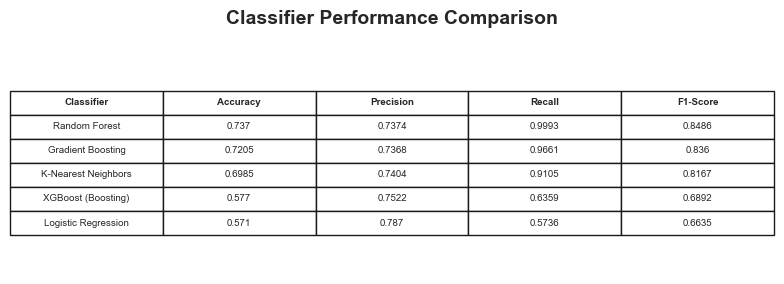

In [74]:
metrics_df = pd.DataFrame([
    {
        'Classifier': name,
        'Accuracy' : round(v['accuracy'],  4),
        'Precision': round(v['precision'], 4),
        'Recall'   : round(v['recall'],    4),
        'F1-Score' : round(v['f1'],        4),
    }
    for name, v in results.items()
]).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print('=== Classifier Performance Comparison ===')
display(metrics_df)

# Save the DataFrame as an image using matplotlib
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=metrics_df.values, colLabels=metrics_df.columns, cellLoc='center', loc='center')
table.scale(1, 1.5)
# Set column headers style
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_fontsize(12)
        cell.set_text_props(weight='bold')

plt.title('Classifier Performance Comparison', pad=20, fontsize=14, fontweight='bold')
plt.tight_layout()
print("\nSaved table image to 'classifier_performance.png'")

### 7.2 Performance Bar Chart

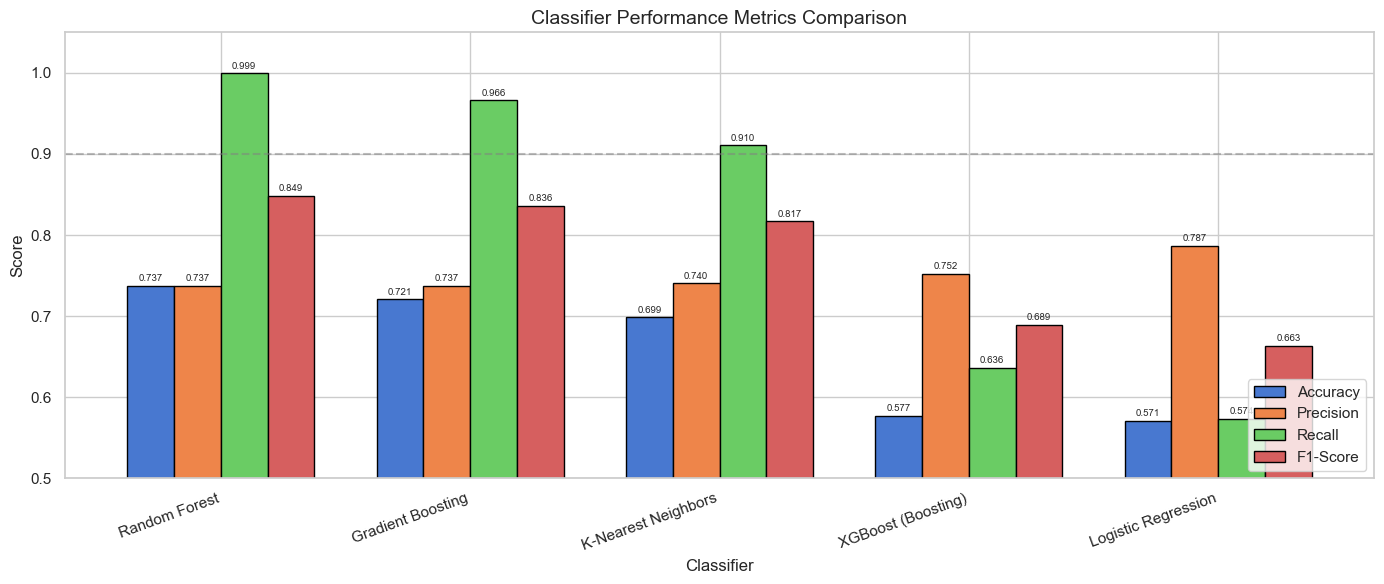

In [75]:
metrics_plot = metrics_df.set_index('Classifier')[['Accuracy','Precision','Recall','F1-Score']]

ax = metrics_plot.plot(kind='bar', figsize=(14, 6), edgecolor='black', width=0.75)
ax.set_title('Classifier Performance Metrics Comparison', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.05)
ax.set_xticklabels(metrics_plot.index, rotation=20, ha='right')
ax.legend(loc='lower right')
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

### 7.3 Classification Reports

In [68]:
for name, v in results.items():
    print(f'{'='*60}')
    print(f'  {name}')
    print(f'{'='*60}')
    print(classification_report(y_test, v['y_pred'],
                                target_names=['Not Selected','Selected']))
    print()

  Logistic Regression
              precision    recall  f1-score   support

Not Selected       0.32      0.56      0.41       525
    Selected       0.79      0.57      0.66      1475

    accuracy                           0.57      2000
   macro avg       0.55      0.57      0.54      2000
weighted avg       0.66      0.57      0.60      2000


  K-Nearest Neighbors
              precision    recall  f1-score   support

Not Selected       0.29      0.10      0.15       525
    Selected       0.74      0.91      0.82      1475

    accuracy                           0.70      2000
   macro avg       0.52      0.51      0.48      2000
weighted avg       0.62      0.70      0.64      2000


  Random Forest
              precision    recall  f1-score   support

Not Selected       0.00      0.00      0.00       525
    Selected       0.74      1.00      0.85      1475

    accuracy                           0.74      2000
   macro avg       0.37      0.50      0.42      2000
weighted avg

### 7.4 Confusion Matrices

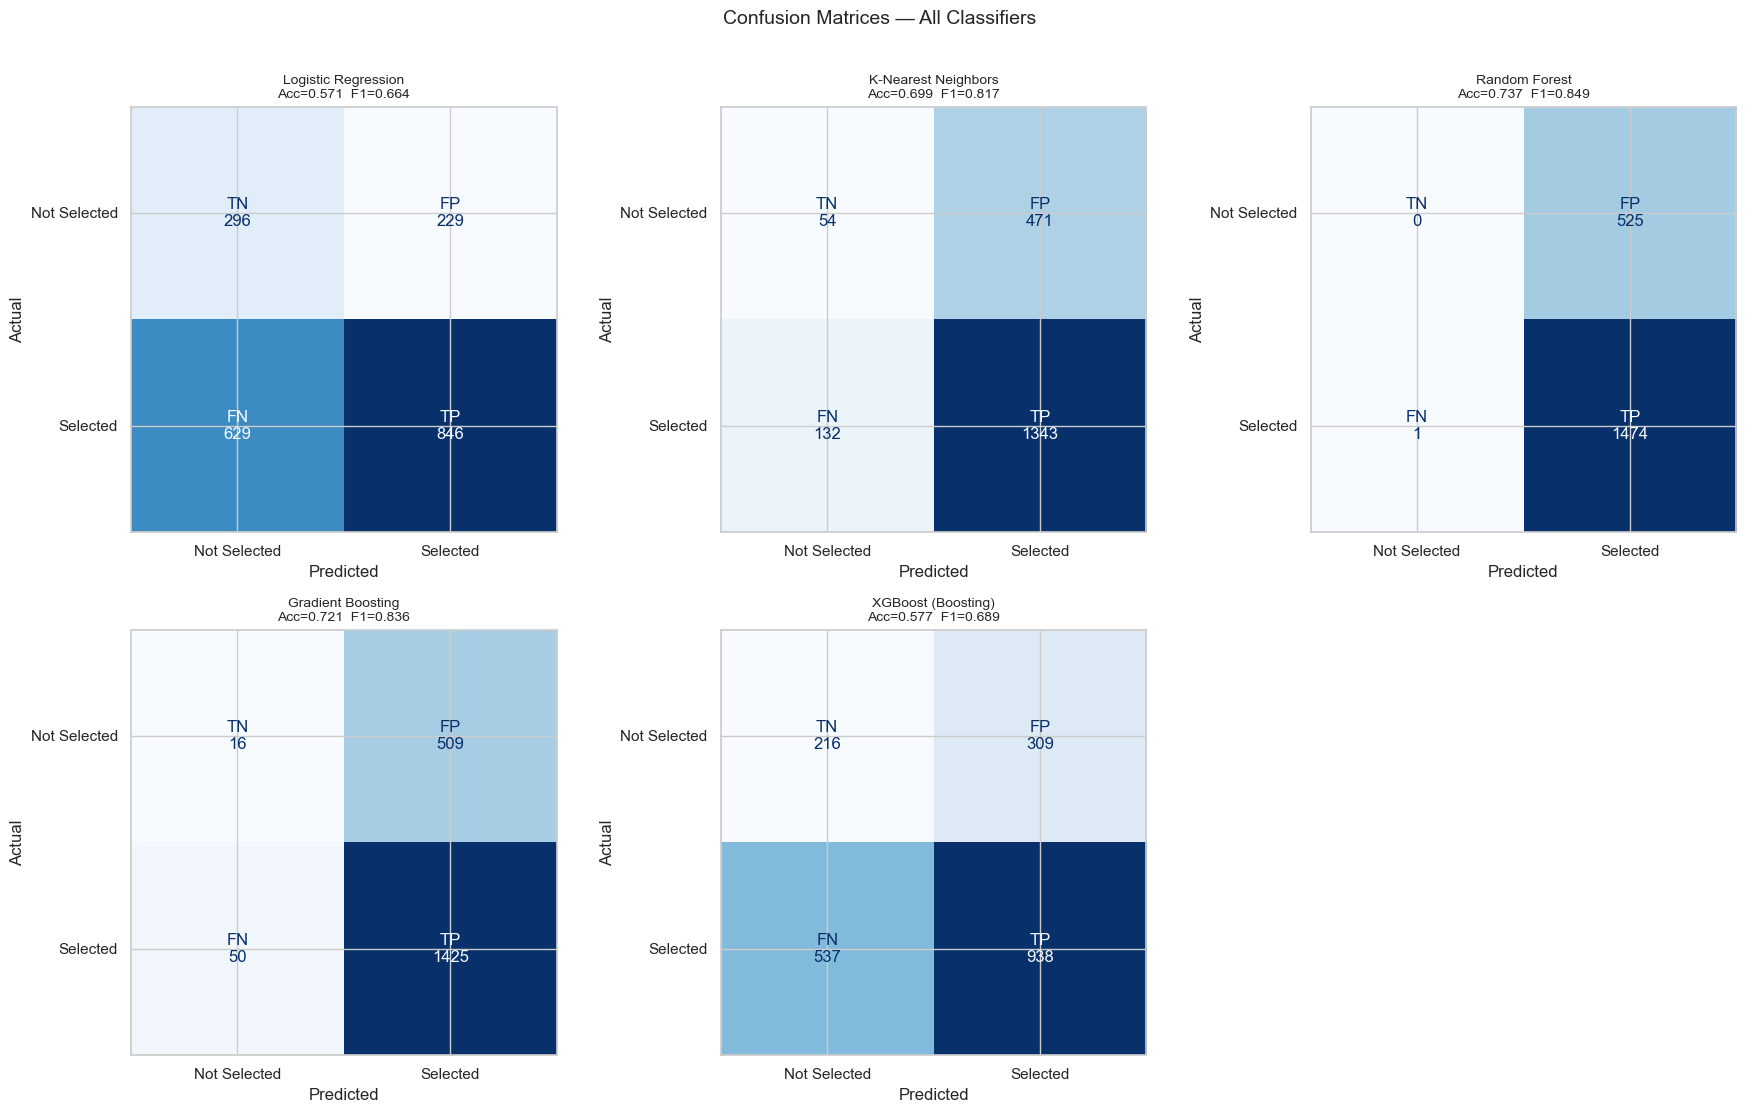

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# Confusion matrix labels layout: 
# [TN, FP]
# [FN, TP]
cm_labels = [['TN', 'FP'], ['FN', 'TP']]

for i, (name, v) in enumerate(results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Selected','Selected'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    
    # Inject TP, TN, FP, FN markers into the rendered text
    for row in range(2):
        for col in range(2):
            val = cm[row, col]
            label = cm_labels[row][col]
            disp.text_[row, col].set_text(f"{label}\n{val}")
            
    axes[i].set_title(f'{name}\nAcc={v["accuracy"]:.3f}  F1={v["f1"]:.3f}', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the unused 6th subplot
axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 7.5 Cross-Validation Scores

Logistic Regression             CV F1: 0.6554 ± 0.0108
K-Nearest Neighbors             CV F1: 0.8221 ± 0.0061
Random Forest                   CV F1: 0.8486 ± 0.0003
Gradient Boosting               CV F1: 0.8389 ± 0.0041
XGBoost (Boosting)              CV F1: 0.7034 ± 0.0133


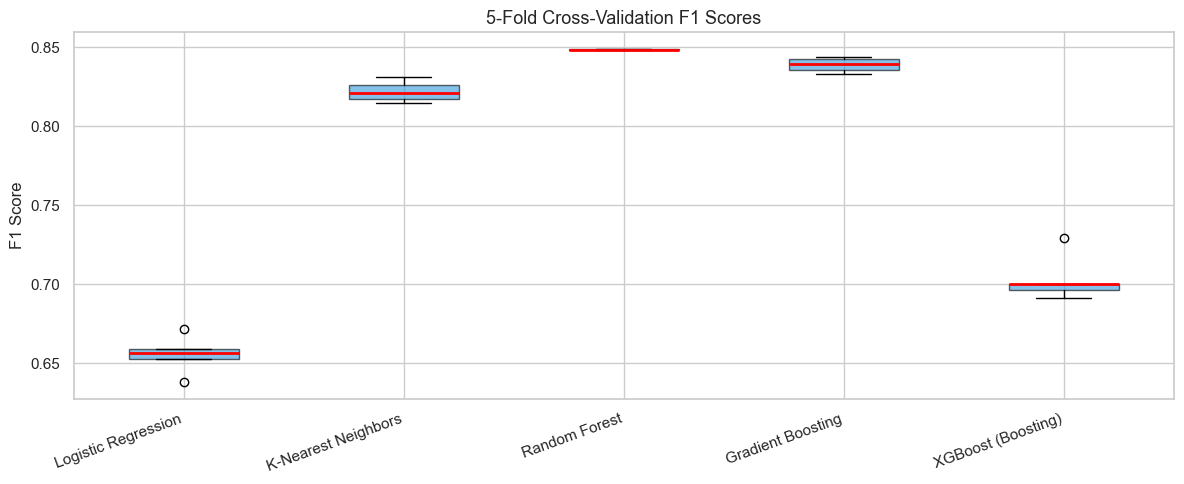

In [70]:
cv_results = {}
# Use the resampled training set for cross-validation (no test leakage)
for name, v in results.items():
    cv_scores = cross_val_score(v['model'], X_train_balanced, y_train_balanced,
                                cv=5, scoring='f1', n_jobs=-1)
    cv_results[name] = cv_scores
    print(f'{name:30s}  CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Boxplot
plt.figure(figsize=(12, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
            boxprops=dict(facecolor='#3498db', alpha=0.6),
            medianprops=dict(color='red', linewidth=2))
plt.xticks(rotation=20, ha='right')
plt.title('5-Fold Cross-Validation F1 Scores', fontsize=13)
plt.ylabel('F1 Score')
plt.tight_layout()
plt.show()

random forest without any balancing is the best model
RF on real data F1=0.8486
Rf with cost sensitive F1=0.8484
GB with smote F1=0.8457


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# DS2: realistic social media dataset
ds2_path = 'realistic_social_media_dataset.csv'
ds2 = pd.read_csv(ds2_path)

X = ds2.drop(columns=['viral'])
y = ds2['viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', encoder, categorical_cols)
    ]
)

# Step 1: Show all engineered features after preprocessing
X_full_prep = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
all_features_df = pd.DataFrame(X_full_prep, columns=feature_names)

# Remove post_id from display (just an identifier)
display_cols = [c for c in all_features_df.columns if 'post_id' not in c]
all_features_display = all_features_df[display_cols]

print('Step 1 - All Features After Preprocessing')
print('=' * 75)
print(f'Original feature count: {X.shape[1]}')
print(f'Engineered feature count after encoding: {all_features_df.shape[1]}')
print(f'Features for visualization (excluding post_id): {len(display_cols)}')
print('\nFeature names (excluding post_id):')
print(display_cols)
print('\nPreview of engineered features:')
display(all_features_display.head())

# Step 2: PCA features
pca_extractor = PCA(n_components=2, random_state=42)
X_pca_2d = pca_extractor.fit_transform(X_full_prep)
pca_features_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])

print('\nStep 2 - PCA Features')
print('=' * 75)
print('Explained variance ratio:')
print(f'PC1: {pca_extractor.explained_variance_ratio_[0]:.4f} ({pca_extractor.explained_variance_ratio_[0]*100:.2f}%)')
print(f'PC2: {pca_extractor.explained_variance_ratio_[1]:.4f} ({pca_extractor.explained_variance_ratio_[1]*100:.2f}%)')
print(f'Cumulative (PC1+PC2): {pca_extractor.explained_variance_ratio_.sum():.4f} ({pca_extractor.explained_variance_ratio_.sum()*100:.2f}%)')
display(pca_features_df.head())

# Step 3: Visualize PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1],
    c=y, cmap='coolwarm', alpha=0.6, s=20, edgecolors='black', linewidth=0.3
 )
axes[0].set_title('PCA Projection (PC1 vs PC2)\ncolored by Viral Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_extractor.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pca_extractor.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Viral (0=No, 1=Yes)', fontsize=9)

bars = axes[1].bar(
    ['PC1', 'PC2'],
    pca_extractor.explained_variance_ratio_,
    color=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=1.5
 )
axes[1].set_title('PCA Explained Variance Ratio', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Variance Ratio', fontsize=10)
axes[1].set_ylim(0, max(pca_extractor.explained_variance_ratio_) * 1.3)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.008, f'{h:.3f} ({h*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Step 4: LDA features
lda_extractor = LinearDiscriminantAnalysis(n_components=1)
X_lda_1d = lda_extractor.fit_transform(X_full_prep, y)
lda_features_df = pd.DataFrame(X_lda_1d, columns=['LD1'])

print('\nStep 4 - LDA Features')
print('=' * 75)
print('LDA components shape:', X_lda_1d.shape)
print(f'LDA explained variance ratio: {lda_extractor.explained_variance_ratio_[0]:.4f}')
display(lda_features_df.head())

# Step 5: Visualize LDA with better separability indicators
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with class distributions
class_0_vals = X_lda_1d[y == 0, 0]
class_1_vals = X_lda_1d[y == 1, 0]

axes[0].hist(class_0_vals, bins=30, alpha=0.6, color='#d62728', label=f'Not Viral (n={len(class_0_vals)})', density=True, edgecolor='black')
axes[0].hist(class_1_vals, bins=30, alpha=0.6, color='#2ca02c', label=f'Viral (n={len(class_1_vals)})', density=True, edgecolor='black')

# Add decision threshold (midpoint)
threshold = (class_0_vals.mean() + class_1_vals.mean()) / 2
axes[0].axvline(threshold, color='purple', linestyle='--', linewidth=2, label=f'Decision Threshold ({threshold:.3f})')

axes[0].set_title('LDA Distribution by Class (LD1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('LD1', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Boxplot
lda_plot_df = lda_features_df.copy()
lda_plot_df['viral'] = y.values
lda_plot_df['viral_label'] = lda_plot_df['viral'].map({0: 'Not Viral', 1: 'Viral'})
sns.boxplot(data=lda_plot_df, x='viral_label', y='LD1', ax=axes[1], palette=['#d62728', '#2ca02c'], width=0.5)
axes[1].axhline(threshold, color='purple', linestyle='--', linewidth=2, label=f'Decision Threshold')
axes[1].set_title('LDA (LD1) by Viral Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Viral Class', fontsize=10)
axes[1].set_ylabel('LD1', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print separability summary
print('\nStep 5 - LDA Separability Analysis')
print('=' * 75)
print(f'Not Viral (Class 0) - Mean LD1: {class_0_vals.mean():.4f}, Std: {class_0_vals.std():.4f}')
print(f'Viral (Class 1)     - Mean LD1: {class_1_vals.mean():.4f}, Std: {class_1_vals.std():.4f}')
print(f'Decision Threshold:   {threshold:.4f}')
print(f'Class Separation Distance: {abs(class_1_vals.mean() - class_0_vals.mean()):.4f}')

Step 1 - All Features After Preprocessing
Original feature count: 29
Engineered feature count after encoding: 44
Features for visualization (excluding post_id): 43

Feature names (excluding post_id):
['num__follower_count', 'num__account_age_days', 'num__hook_strength', 'num__relatability_score', 'num__thumbnail_quality', 'num__caption_length', 'num__hashtag_count', 'num__trending_audio', 'num__call_to_action', 'num__video_duration', 'num__post_time', 'num__day_of_week', 'num__views', 'num__likes', 'num__comments', 'num__shares', 'num__saves', 'num__impressions', 'num__reach', 'num__watch_time_avg', 'num__completion_rate', 'num__engagement_rate', 'num__first_3sec_retention', 'cat__platform_Instagram', 'cat__platform_TikTok', 'cat__platform_YouTube', 'cat__content_type_Post', 'cat__content_type_Reel', 'cat__content_type_Short', 'cat__content_type_Video', 'cat__category_Education', 'cat__category_Entertainment', 'cat__category_Meme', 'cat__category_Motivation', 'cat__category_Tech', 'cat

,num__follower_count,num__account_age_days,num__hook_strength,num__relatability_score,num__thumbnail_quality,num__caption_length,num__hashtag_count,num__trending_audio,num__call_to_action,num__video_duration,...,cat__category_Motivation,cat__category_Tech,cat__creator_type_brand,cat__creator_type_individual,cat__creator_type_influencer,cat__emotion_trigger_curiosity,cat__emotion_trigger_fear,cat__emotion_trigger_funny,cat__emotion_trigger_inspiration,cat__emotion_trigger_neutral
0,-0.133478,0.210057,0.911872,-0.175149,0.513402,-0.208668,-0.098098,-1.018844,1.004008,-0.232064,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-0.359098,0.124028,1.614393,-0.877617,0.513402,1.263714,-1.474905,-1.018844,1.004008,-0.703314,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.303541,0.163458,-0.493170,-1.228851,0.860139,-1.656913,-1.216753,0.981504,-0.996008,-0.644408,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.343001,-1.211215,-0.141909,0.878554,1.553613,0.937859,0.762407,-1.018844,-0.996008,-1.410189,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-0.067525,-1.456756,0.911872,-1.228851,-1.567020,-1.101752,0.246104,0.981504,-0.996008,-0.487325,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0



Step 2 - PCA Features
Explained variance ratio:
PC1: 0.2468 (24.68%)
PC2: 0.0718 (7.18%)
Cumulative (PC1+PC2): 0.3185 (31.85%)


,PC1,PC2
0,-0.263091,1.694641
1,-0.568289,2.534099
2,-0.456201,-1.338470
3,-0.746361,0.549400
4,-0.149307,0.928305


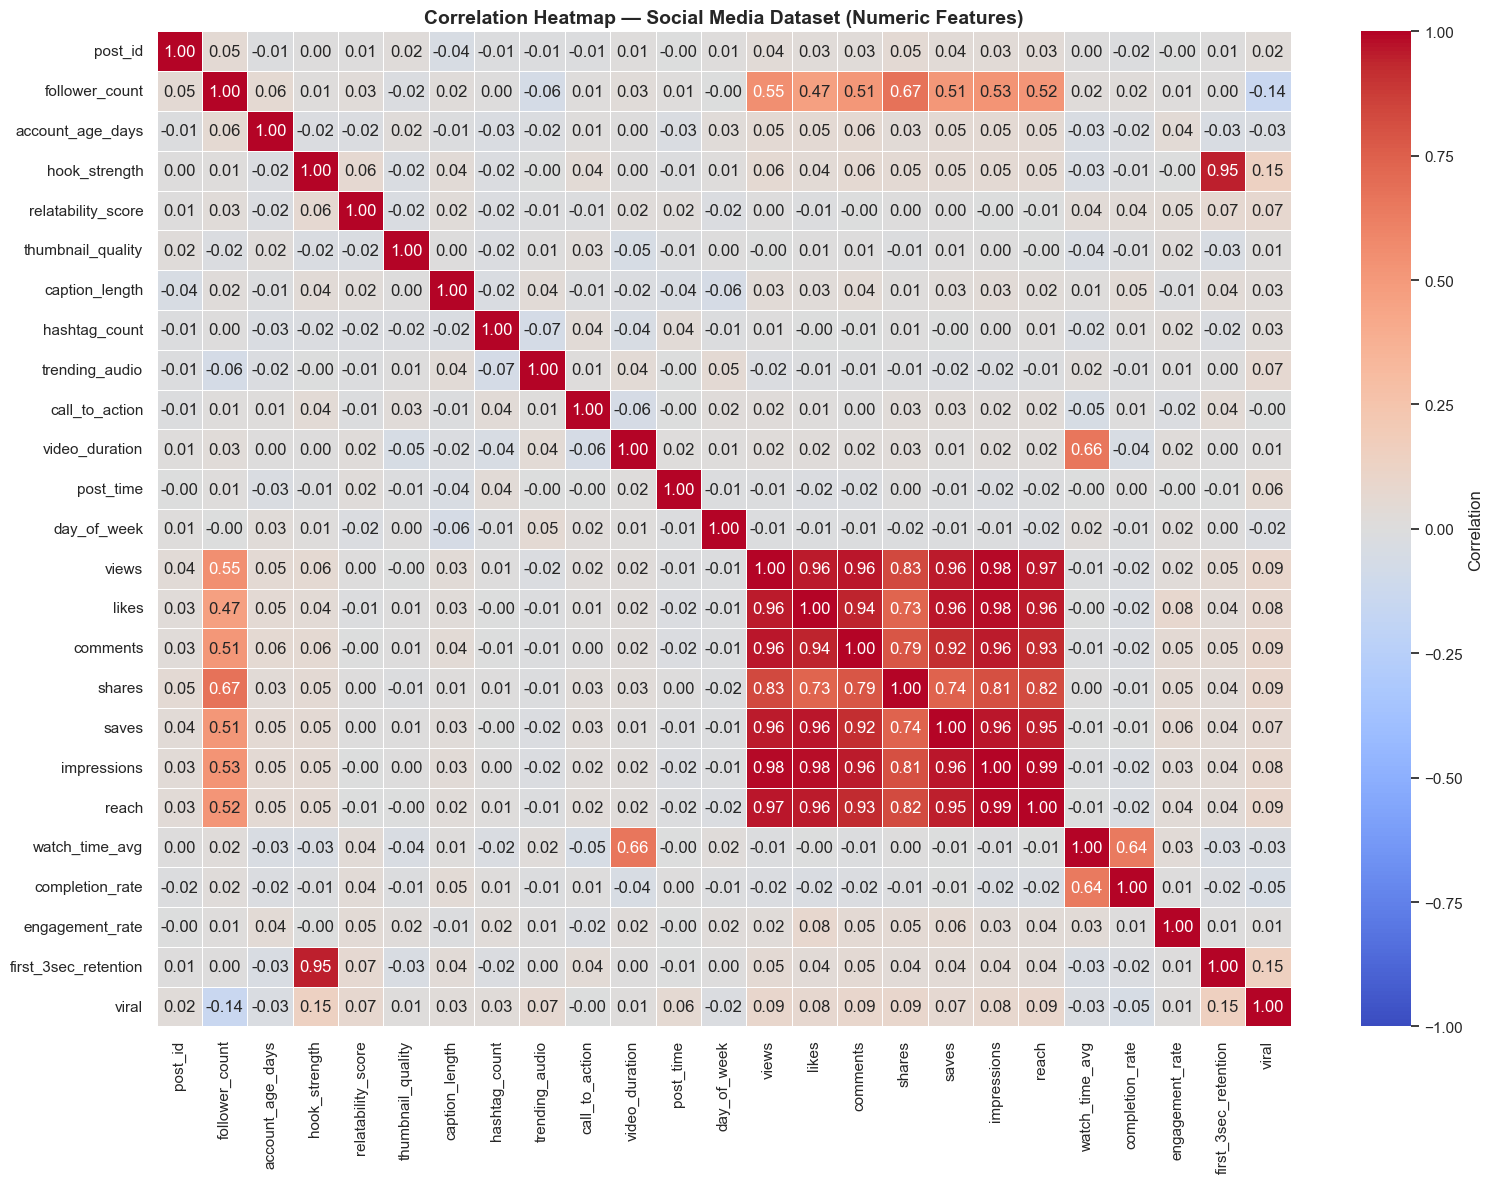

In [31]:
# Create correlation heatmap for social media dataset (numeric columns only)
numeric_ds2 = ds2.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 12))
sns.heatmap(
    numeric_ds2.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Heatmap — Social Media Dataset (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# DS2 leakage-safe experiment: predict virality using only pre-posting features
leakage_columns = [
    'views', 'likes', 'comments', 'shares', 'saves',
    'impressions', 'reach', 'watch_time_avg',
    'completion_rate', 'engagement_rate', 'first_3sec_retention'
 ]
identifier_columns = ['post_id']

drop_cols = [c for c in leakage_columns + identifier_columns if c in ds2.columns]
print('Dropping leakage/identifier columns:', drop_cols)

X_no_leak = ds2.drop(columns=['viral'] + drop_cols)
y_no_leak = ds2['viral']

X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_no_leak, y_no_leak, test_size=0.2, random_state=42, stratify=y_no_leak
)

categorical_cols_nl = X_no_leak.select_dtypes(include=['object']).columns.tolist()
numeric_cols_nl = X_no_leak.select_dtypes(exclude=['object']).columns.tolist()

try:
    encoder_nl = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder_nl = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor_nl = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_nl),
        ('cat', encoder_nl, categorical_cols_nl)
    ]
)

classifiers_nl = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=2.0, gamma='scale', random_state=42)
}

feature_extractors_nl = {
    'PCA': PCA(n_components=0.95, random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

results_no_leak = []
for fe_name, extractor in feature_extractors_nl.items():
    for clf_name, clf in classifiers_nl.items():
        pipe_nl = Pipeline(steps=[
            ('prep', preprocessor_nl),
            ('fe', extractor),
            ('clf', clf)
        ])
        pipe_nl.fit(X_train_nl, y_train_nl)
        y_pred_nl = pipe_nl.predict(X_test_nl)
        results_no_leak.append({
            'Feature_Extraction': fe_name,
            'Classifier': clf_name,
            'Accuracy': accuracy_score(y_test_nl, y_pred_nl),
            'Precision': precision_score(y_test_nl, y_pred_nl, zero_division=0),
            'Recall': recall_score(y_test_nl, y_pred_nl, zero_division=0),
            'F1-Score': f1_score(y_test_nl, y_pred_nl, zero_division=0)
        })

results_df_no_leak = pd.DataFrame(results_no_leak).sort_values(
    by='F1-Score', ascending=False
).reset_index(drop=True)

print('\nDS2 Results WITHOUT leakage features (production-realistic)')
print('=' * 75)
display(results_df_no_leak)

if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    old_best = results_df.iloc[0]
    new_best = results_df_no_leak.iloc[0]
    comparison = pd.DataFrame([
        {
            'Setting': 'With leakage features',
            'Best Model': f"{old_best['Feature_Extraction']} + {old_best['Classifier']}",
            'Accuracy': round(float(old_best['Accuracy']), 4),
            'Precision': round(float(old_best['Precision']), 4),
            'Recall': round(float(old_best['Recall']), 4),
            'F1-Score': round(float(old_best['F1-Score']), 4)
        },
        {
            'Setting': 'Without leakage features',
            'Best Model': f"{new_best['Feature_Extraction']} + {new_best['Classifier']}",
            'Accuracy': round(float(new_best['Accuracy']), 4),
            'Precision': round(float(new_best['Precision']), 4),
            'Recall': round(float(new_best['Recall']), 4),
            'F1-Score': round(float(new_best['F1-Score']), 4)
        }
    ])
    print('\nBest-model comparison')
    print('=' * 75)
    display(comparison)
else:
    print('\nPrevious results_df not found, so only leakage-safe results are shown.')

Dropping leakage/identifier columns: ['views', 'likes', 'comments', 'shares', 'saves', 'impressions', 'reach', 'watch_time_avg', 'completion_rate', 'engagement_rate', 'first_3sec_retention', 'post_id']

DS2 Results WITHOUT leakage features (production-realistic)


,Feature_Extraction,Classifier,Accuracy,Precision,Recall,F1-Score
0,PCA,Logistic Regression,0.593333,0.596026,0.596026,0.596026
1,PCA,SVM (RBF),0.583333,0.586667,0.582781,0.584718
2,PCA,Random Forest,0.586667,0.595745,0.556291,0.575342
3,LDA,SVM (RBF),0.566667,0.572414,0.549669,0.560811
4,LDA,Logistic Regression,0.570000,0.577465,0.543046,0.559727
5,LDA,Random Forest,0.550000,0.552632,0.556291,0.554455



Best-model comparison


,Setting,Best Model,Accuracy,Precision,Recall,F1-Score
0,With leakage features,PCA + Logistic Regression,0.7867,0.800,0.7682,0.7838
1,Without leakage features,PCA + Logistic Regression,0.5933,0.596,0.5960,0.5960
